# Codeforces Intelligence Dashboard

Analyze your Codeforces competitive programming performance with comprehensive visualizations.

## Features
- **Rating Progression**: Track official rating changes over contest history
- **Practice Trends**: Visualize problem difficulty growth during practice sessions
- **Skill Analysis**: Analyze performance across different algorithmic topics
- **Performance Metrics**: Calculate gaps between practice difficulty and current rating

## Setup
1. Install dependencies: `pip install requests pandas matplotlib seaborn numpy`
2. Update `USERNAME` variable below with your Codeforces handle
3. Run all cells

## Data Source
Uses the official [Codeforces API](https://codeforces.com/apiHelp) for all data

In [1]:
# Configuration: Update this with your Codeforces handle
USERNAME = "jalanashutosh06"

## Import Required Libraries

In [2]:
import requests
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')




c:\Users\Ashutosh\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.18) or chardet (7.2.0)/charset_normalizer (3.1.0) doesn't match a supported version!
  warnings.warn(


## Fetch User Data from Codeforces API

Query submissions and rating history for the configured user

In [3]:
try:
    print(f"Fetching data for user: {USERNAME}")
    
    # Fetch submission history
    submissions_url = f"https://codeforces.com/api/user.status?handle={USERNAME}&from=1&count=10000"
    ratings_url = f"https://codeforces.com/api/user.rating?handle={USERNAME}"
    
    submissions_resp = requests.get(submissions_url, timeout=15).json()
    ratings_resp = requests.get(ratings_url, timeout=15).json()
    
    if submissions_resp["status"] != "OK" or ratings_resp["status"] != "OK":
        raise Exception(f"API Error: {submissions_resp.get('comment', 'Unknown error')}")
    
    submissions = submissions_resp["result"]
    ratings_data = ratings_resp["result"]
    
    print(f"✓ Fetched {len(submissions)} submissions")
    print(f"✓ Fetched {len(ratings_data)} contest participations")
    
except requests.exceptions.RequestException as e:
    print(f"Network error: {e}")
    raise

Fetching data for user: jalanashutosh06
✓ Fetched 76 submissions
✓ Fetched 4 contest participations


## Clean and Process Submissions Data

Remove duplicates and filter for successful submissions

In [4]:
# Remove duplicate problems (keep first occurrence)
seen = set()
unique_submissions = []

for sub in submissions:
    prob = sub.get("problem", {})
    contest_id = prob.get("contestId")
    index = prob.get("index")
    
    if contest_id and index:
        key = (contest_id, index)
        if key not in seen:
            seen.add(key)
            unique_submissions.append(sub)

submissions = unique_submissions
print(f"✓ Deduplicated to {len(submissions)} unique problems")

# Prepare practice data
practice_data = []
contests_data = []

for sub in submissions:
    if sub.get("verdict") == "OK":
        date_ts = sub.get("creationTimeSeconds", 0)
        prob = sub.get("problem", {})
        
        try:
            date_obj = datetime.fromtimestamp(date_ts)
            problem_rating = prob.get("rating", 1000)
            tags = prob.get("tags", ["Unknown"])
            primary_tag = tags[0].title() if tags else "Unknown"
            
            practice_data.append({
                "date": date_obj,
                "problem_rating": problem_rating,
                "tag": primary_tag,
                "contest_id": prob.get("contestId"),
                "problem_index": prob.get("index")
            })
        except:
            pass

# Prepare contest data
for contest in ratings_data:
    date_ts = contest.get("ratingUpdateTimeSeconds", 0)
    try:
        date_obj = datetime.fromtimestamp(date_ts)
        contests_data.append({
            "date": date_obj,
            "rating": contest.get("newRating"),
            "old_rating": contest.get("oldRating")
        })
    except:
        pass

df_practice = pd.DataFrame(practice_data).sort_values("date").reset_index(drop=True)
df_contests = pd.DataFrame(contests_data).sort_values("date").reset_index(drop=True)

print(f"✓ Processed {len(df_practice)} solved problems")
print(f"✓ Processed {len(df_contests)} contests")

✓ Deduplicated to 55 unique problems
✓ Processed 51 solved problems
✓ Processed 4 contests


## Calculate User Statistics

In [5]:
# Match practice to contest ratings
if not df_practice.empty and not df_contests.empty:
    merged = pd.merge_asof(
        df_practice,
        df_contests,
        on="date",
        direction="backward",
        suffixes=("", "_contest")
    )
    merged = merged.dropna(subset=["rating"])
    
    # Calculate performance gap
    merged["gap"] = merged["problem_rating"] - merged["rating"]
    merged["rolling_difficulty"] = merged["problem_rating"].rolling(window=20, min_periods=1).mean()
    
    df_practice = merged

# Topic skill analysis
if not df_practice.empty:
    topic_stats = df_practice.groupby("tag").agg({
        "problem_rating": ["count", "mean", "max"],
        "gap": "mean"
    }).round(2)
    
    topic_stats.columns = ["Solves", "Avg Rating", "Max Rating", "Avg Gap"]
    topic_stats = topic_stats.sort_values("Avg Rating", ascending=False)
    
    print("\n=== Topic Skill Summary ===\n")
    print(topic_stats)

# Overall statistics
print("\n=== Overall Statistics ===")
if not df_practice.empty:
    print(f"Total Problems Solved: {len(df_practice)}")
    print(f"Average Problem Rating: {df_practice['problem_rating'].mean():.0f}")
    print(f"Max Problem Rating: {df_practice['problem_rating'].max():.0f}")
    print(f"Average Performance Gap: {df_practice['gap'].mean():.0f}")

if not df_contests.empty:
    current_rating = df_contests.iloc[-1]["rating"]
    peak_rating = df_contests["rating"].max()
    print(f"\nCurrent Rating: {current_rating:.0f}")
    print(f"Peak Rating: {peak_rating:.0f}")


=== Topic Skill Summary ===

                         Solves  Avg Rating  Max Rating  Avg Gap
tag                                                             
Dfs And Similar               1     1200.00        1200   497.00
Binary Search                 3     1100.00        1300   189.00
Combinatorics                 1     1000.00        1000    89.00
Strings                       1     1000.00        1000    89.00
Dp                            1     1000.00        1000    89.00
Constructive Algorithms       5      920.00        1000   247.40
Brute Force                   4      900.00        1000   135.00
Math                          3      866.67        1000   283.67
Greedy                       13      838.46        1000   136.69
Geometry                      1      800.00         800  -227.00
Implementation                2      800.00         800   381.00

=== Overall Statistics ===
Total Problems Solved: 35
Average Problem Rating: 903
Max Problem Rating: 1300
Average Performanc

## Create Comprehensive Intelligence Report

Generate multi-panel dashboard with detailed visualizations

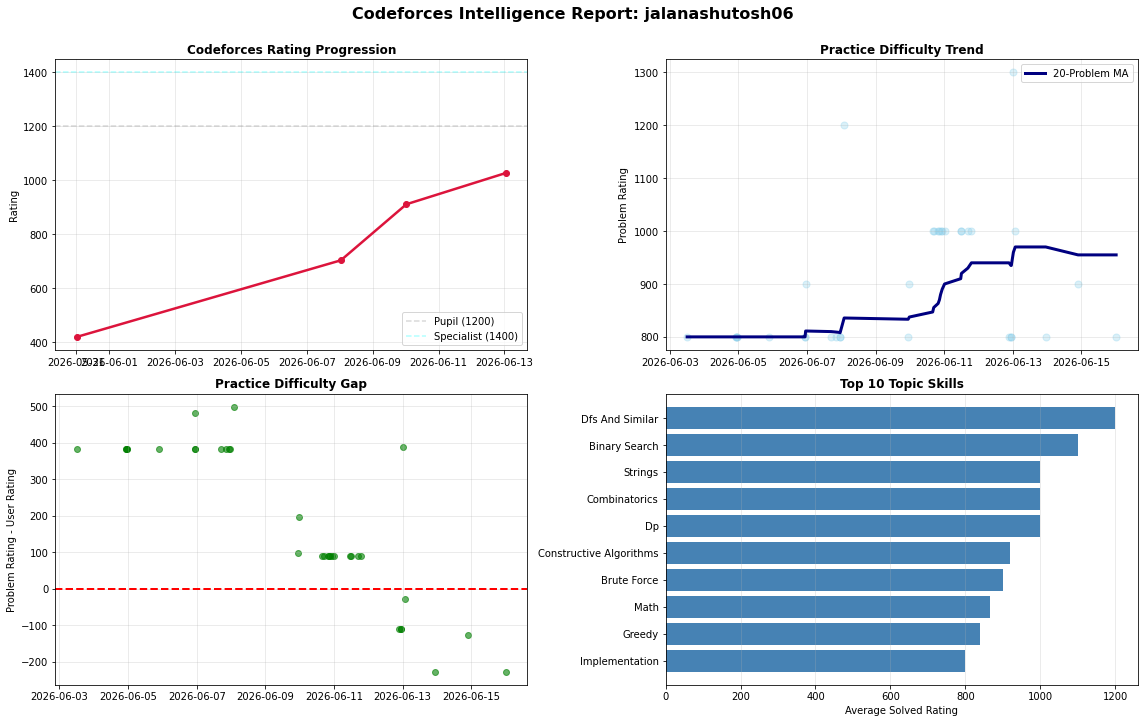

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Rating Progression
if not df_contests.empty:
    axes[0, 0].plot(df_contests["date"], df_contests["rating"], 
                    marker="o", linewidth=2.5, color="crimson", markersize=6)
    axes[0, 0].axhline(y=1200, color="gray", linestyle="--", alpha=0.3, label="Pupil (1200)")
    axes[0, 0].axhline(y=1400, color="cyan", linestyle="--", alpha=0.3, label="Specialist (1400)")
    axes[0, 0].set_title("Codeforces Rating Progression", fontsize=12, fontweight="bold")
    axes[0, 0].set_ylabel("Rating")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

# Panel 2: Practice Difficulty Trend
if not df_practice.empty:
    axes[0, 1].scatter(df_practice["date"], df_practice["problem_rating"], 
                       alpha=0.3, s=50, color="skyblue")
    if "rolling_difficulty" in df_practice.columns:
        axes[0, 1].plot(df_practice["date"], df_practice["rolling_difficulty"], 
                       linewidth=3, color="navy", label="20-Problem MA")
    axes[0, 1].set_title("Practice Difficulty Trend", fontsize=12, fontweight="bold")
    axes[0, 1].set_ylabel("Problem Rating")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

# Panel 3: Performance Gap
if not df_practice.empty and "gap" in df_practice.columns:
    axes[1, 0].scatter(df_practice["date"], df_practice["gap"], alpha=0.6, color="green")
    axes[1, 0].axhline(y=0, linestyle="--", color="red", linewidth=2)
    axes[1, 0].set_title("Practice Difficulty Gap", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylabel("Problem Rating - User Rating")
    axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Topic Skill Distribution
if not df_practice.empty:
    topic_avg = df_practice.groupby("tag")["problem_rating"].mean().sort_values(ascending=True).tail(10)
    axes[1, 1].barh(range(len(topic_avg)), topic_avg.values, color="steelblue")
    axes[1, 1].set_yticks(range(len(topic_avg)))
    axes[1, 1].set_yticklabels(topic_avg.index)
    axes[1, 1].set_title("Top 10 Topic Skills", fontsize=12, fontweight="bold")
    axes[1, 1].set_xlabel("Average Solved Rating")
    axes[1, 1].grid(True, alpha=0.3, axis="x")

plt.suptitle(f"Codeforces Intelligence Report: {USERNAME}", 
             fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()